In [3]:
import pandas as pd
import numpy as np

In [4]:
from sklearn.datasets import load_iris
iris = load_iris()
dir(load_iris())

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [5]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
df['target'] = iris.target #1 column appended
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [9]:
len(df[df.target == 1])

50

In [10]:
len(df[df.target == 2])

50

In [11]:
len(df[df.target == 0])

50

In [12]:
df['flower_name']= df.target.apply(lambda x: iris.target_names[x])

In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [14]:
X = df.drop(['target', 'flower_name'], axis='columns')

In [15]:
y = df.target

In [16]:
from sklearn.model_selection import train_test_split
trainX, testX, trainY, testY = train_test_split(X, y, test_size = 0.1) 

In [17]:
from sklearn.svm import SVC
model = SVC()

In [18]:
model.fit(trainX, trainY)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
model.predict(testX)

array([0, 0, 0, 1, 2, 0, 0, 1, 1, 0, 2, 2, 0, 1, 1])

In [20]:
model.score(trainX, trainY)

0.9703703703703703

In [21]:
model.score(testX, testY)

1.0

Matplotlib is building the font cache; this may take a moment.


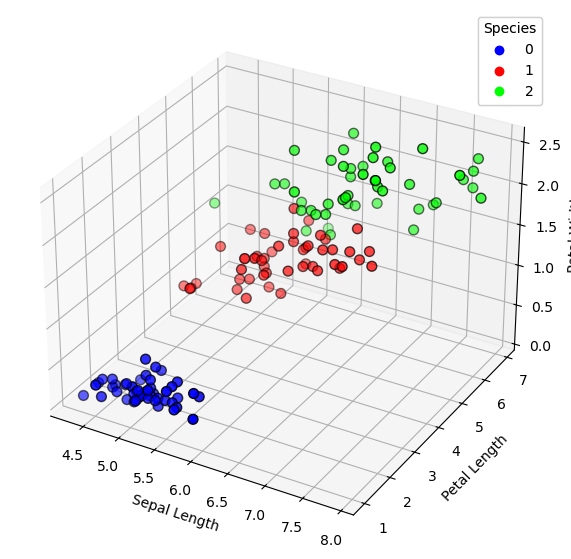

In [22]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot all 3 categories (target 0, 1, and 2)
# cmap='brg' or 'jet' works well for 3 distinct colors
scatter = ax.scatter(df['sepal length (cm)'], 
                     df['petal length (cm)'], 
                     df['petal width (cm)'], 
                     c=df['target'], 
                     cmap='brg', 
                     edgecolor='k',
                     s=50)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Petal Length')
ax.set_zlabel('Petal Width')

# Add a legend for the 3 species
legend1 = ax.legend(*scatter.legend_elements(), title="Species")
ax.add_artist(legend1)

plt.show()


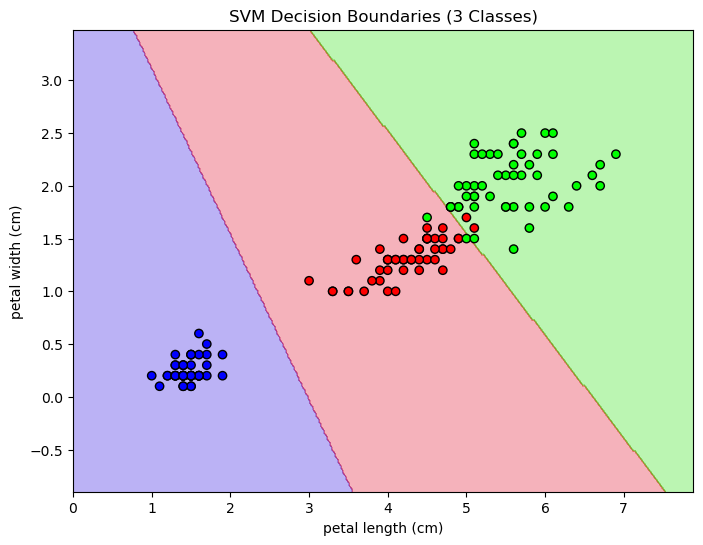

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import load_iris

# 1. Setup Data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# 2. Train SVM (Using only 2 features for 2D visualization)
features = ['petal length (cm)', 'petal width (cm)']
model = SVC(kernel='linear')
model.fit(df[features], df['target'])

# 3. Create Mesh Grid
x_min, x_max = df[features[0]].min() - 1, df[features[0]].max() + 1
y_min, y_max = df[features[1]].min() - 1, df[features[1]].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Predict using DataFrame to avoid Feature Name Warning
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=features)
Z = model.predict(grid_df)
Z = Z.reshape(xx.shape)

# 5. Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='brg')
plt.scatter(df[features[0]], df[features[1]], c=df['target'], cmap='brg', edgecolor='k')

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("SVM Decision Boundaries (3 Classes)")
plt.show()

